In [ ]:
# LIBRARY
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# UPLOAD / LOAD DATASET PASCAL VOC FORMAT
# dataset/
#   |- images/
#   |- annotations/ (format XML Pascal VOC)

import glob
import xml.etree.ElementTree as ET


In [3]:

class PascalVOCDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image'])
        image = Image.open(img_path).convert("RGB")

        boxes = []
        labels = []

        for box, label in zip(row['boxes'], row['labels']):
            boxes.append(box)
            labels.append(label)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}

        if self.transform:
            image = self.transform(image)

        return image, target

    def __len__(self):
        return len(self.df)



In [ ]:
# PARSE XML ANNOTASI PASCAL VOC -> DataFrame
def parse_voc_annotation(xml_folder, img_folder):
    data = []
    for xml_file in glob.glob(os.path.join(xml_folder, "*.xml")):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        filename = root.find("filename").text
        boxes = []
        labels = []
        for obj in root.findall("object"):
            label = obj.find("name").text
            bndbox = obj.find("bndbox")
            bbox = [
                float(bndbox.find("xmin").text),
                float(bndbox.find("ymin").text),
                float(bndbox.find("xmax").text),
                float(bndbox.find("ymax").text)
            ]
            boxes.append(bbox)
            labels.append(label)

        data.append({"image": filename, "boxes": boxes, "labels": labels})

    return pd.DataFrame(data)



In [ ]:
# LOAD DATASET
xml_dir = "dataset_pv/annotations"
img_dir = "dataset_pv/images"
dataset = parse_voc_annotation(xml_dir, img_dir)
unique_imgs = dataset['image'].unique()



In [ ]:
# SPLIT DATA
train_inds, val_inds = train_test_split(range(unique_imgs.shape[0]), test_size=0.1, random_state=42)
train_imgs = unique_imgs[train_inds]
val_imgs = unique_imgs[val_inds]

train_df = dataset[dataset['image'].isin(train_imgs)]
val_df = dataset[dataset['image'].isin(val_imgs)]

print(f"Train samples: {len(train_df)}, Validation samples: {len(val_df)}")



Train samples: 135, Validation samples: 15


In [ ]:
# COLLATE FUNCTION (untuk Faster R-CNN)
def custom_collate(batch):
    return tuple(zip(*batch))



In [ ]:
#  CONVERT LABEL KE INTEGER
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset['labels'] = dataset['labels'].apply(lambda labels: le.fit_transform(labels))
train_df['labels'] = train_df['labels'].apply(lambda labels: le.transform(labels))
val_df['labels'] = val_df['labels'].apply(lambda labels: le.transform(labels))

# LOAD DATALOADER
train_dataset = PascalVOCDataset(train_df, img_dir, transform=F.to_tensor)
val_dataset = PascalVOCDataset(val_df, img_dir, transform=F.to_tensor)

train_dl = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=custom_collate,
                      pin_memory=torch.cuda.is_available())
val_dl = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=custom_collate,
                    pin_memory=torch.cuda.is_available())



<ipython-input-8-bf1d95f6ee6b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['labels'] = train_df['labels'].apply(lambda labels: le.transform(labels))
<ipython-input-8-bf1d95f6ee6b>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['labels'] = val_df['labels'].apply(lambda labels: le.transform(labels))


In [ ]:
# INISIALISASI MODEL & OPTIMIZER
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(le.classes_) + 1  # +1 untuk background

model = fasterrcnn_resnet50_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=0.0001)



c:\Users\acer\AppData\Local\Programs\PythonCodingPack\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\acer\AppData\Local\Programs\PythonCodingPack\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# TRAINING LOOP
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for images, targets in train_dl:
        images = [img.to(device) for img in images]
        targets = [{"boxes": t['boxes'].to(device), "labels": t['labels'].to(device)} for t in targets]

        if any(t['boxes'].numel() == 0 for t in targets):
            continue

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")



Epoch [1/10], Loss: 3.1706
Epoch [2/10], Loss: 0.8585
Epoch [3/10], Loss: 0.4573
Epoch [4/10], Loss: 0.2611
Epoch [5/10], Loss: 0.2283
Epoch [6/10], Loss: 0.2326
Epoch [7/10], Loss: 0.1660
Epoch [8/10], Loss: 0.1022
Epoch [9/10], Loss: 0.4441
Epoch [10/10], Loss: 0.2323


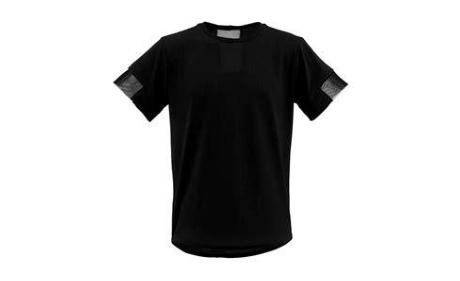

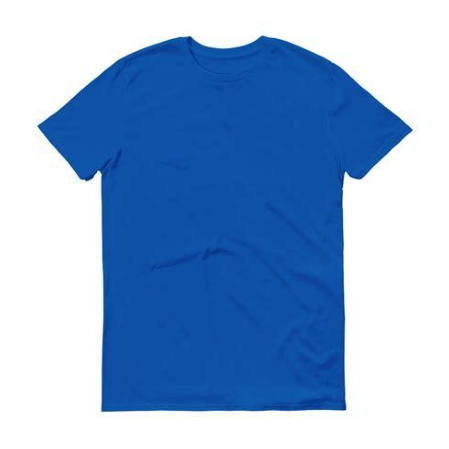

In [ ]:
# VISUALISASI HASIL PREDIKSI
model.eval()
import random

images, targets = next(iter(val_dl))
images = [img.to(device) for img in images]
outputs = model(images)

all_preds = []
all_gts = []

for i in range(len(images)):
    img = images[i].permute(1, 2, 0).cpu().numpy()
    preds = outputs[i]

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img)

    boxes = preds['boxes'].detach().cpu().numpy()
    scores = preds['scores'].detach().cpu().numpy()
    labels = preds['labels'].detach().cpu().numpy()

    gt_labels = targets[i]['labels'].cpu().numpy()

    pred_labels = []
    for box, score, label in zip(boxes, scores, labels):
        if score > 0.5:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            ax.text(xmin, ymin, f"{le.inverse_transform([label-1])[0]}: {score:.2f}",
                    color='white', backgroundcolor='red', fontsize=8)
            pred_labels.append(label)

    all_preds.extend(pred_labels)
    all_gts.extend(gt_labels.tolist())

    plt.axis('off')
    plt.show()

In [12]:
torch.save(model.state_dict(), "fasterrcnn_pascalvoc.pth")
print("Model disimpan sebagai 'fasterrcnn_pascalvoc.pth'")

Model disimpan sebagai 'fasterrcnn_pascalvoc.pth'


In [ ]:
# EVALUASI mAP ATAU F1-SCORE
from sklearn.metrics import precision_recall_fscore_support


if all_preds and all_gts:
    precision, recall, f1, _ = precision_recall_fscore_support(all_gts, all_preds, average='weighted')
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")
else:
    print("Tidak ada prediksi yang lolos threshold untuk evaluasi.")


Tidak ada prediksi yang lolos threshold untuk evaluasi.
